# Linus's Simple Event Volatility Model: Core Simulator

This notebook is a clean rebuild of Linus' model from its mathematical specification. It implements and mechanically validates only the core synthetic simulator for the dense periodic $n=1$ reference case. It intentionally excludes estimation, causal analysis, forecasting, real data, and robustness work.

## 1. Model equations and notation

The price process is

$$S_{i+1}=S_i+\sigma_i S_i\epsilon_i=S_i(1+\sigma_i\epsilon_i),\qquad \epsilon_i\sim N(0,\Delta t_i).$$

Define $x_i=\sigma_i^n$. The state transition is

$$x_{i+1}=\omega_{i+1}^{n/2}\left[x_i+\alpha_i\Delta t_i+\nu_i\left(\rho_i\epsilon_i+\sqrt{1-\rho_i^2}\eta_i\right)\right],$$

where $\eta_i\sim N(0,\Delta t_i)$ is independent of $\epsilon_i$. The same $\epsilon_i$ is used in both transitions. The reference run uses $n=1$, so $x_i=\sigma_i$; the short smoke test uses $n=2$, so $x_i=\sigma_i^2$.

## 2. Timing convention

The source-time convention is $E_i \rightarrow \omega_{i+1} \rightarrow x_{i+1}$. At $t_i$, the simulator has $S_i$, $\sigma_i$, $x_i$, historical log returns through $t_i$, and $E_i$. It evaluates the functional forms and the event weight at source time $t_i$, draws shocks, then produces $S_{i+1}$ and $x_{i+1}$. Thus an event observed at $t_i$ affects the transition $i\rightarrow i+1$; its stored weight is named `omega_next` to make this indexing explicit.

## 3. Imports and reproducibility

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 6)

## 4. Reference configuration

Time is measured in years on a 252-step trading-year grid. The $n=1$ parameters represent an annualised volatility level: `theta` is the long-run volatility, `kappa` is its mean-reversion speed, `nu_0` is volatility-of-volatility, and `rho_0` is the price/volatility shock correlation. Periodic events begin after 42 steps and recur every 42 steps. Their 12-step response horizon is shorter than the period, so response windows do not overlap in this benchmark. `amplitude` controls the initial weight uplift and `decay_rate` controls how quickly it fades.

In [27]:
reference_config = {
    'simulation': {
        'trading_steps_per_year': 252,
        'years': 2,
        'S0': 100.0,
        'sigma0': 0.20,
        'seed': 20260721, # Fixed Random Seed
    },
    'model': {
        'n': 1,
        'kappa': 1.50,
        'theta': 0.20,
        'nu_0': 0.015,
        'rho_0': -0.35,
    },
    'events': {
        'amplitude': 0.01,
        'decay_rate': 35.0,
        'period': 21 / 252,
        'first_event_time': 21 / 252,
        'response_horizon': 12 / 252,
    },
    'validation': {
        'tolerance': 1e-12,
        'different_seed': 20260722,
        'n2_steps': 84,
        'n2_seed': 20260723,
        'n2_model': {
            'n': 2,
            'kappa': 1.50,
            'theta': 0.04,
            'nu_0': 0.002,
            'rho_0': -0.25,
        },
    },
}

steps_per_year = reference_config['simulation']['trading_steps_per_year']
n_steps = reference_config['simulation']['years'] * steps_per_year
time_grid = np.arange(n_steps + 1, dtype=float) / steps_per_year

## 5. Functional forms

The simulator receives all model behaviour through these interfaces. `returns` is always the historical log-return array available at the source time; it is empty at the initial state. The reference forms are mean reversion in $x$, with constant strictly positive $\nu$ and constant $\rho$ strictly inside $(-1,1)$.

In [28]:
def alpha_fn(t, S, sigma, returns, params):
    x = sigma ** params['n']
    return params['kappa'] * (params['theta'] - x)


def nu_fn(t, S, sigma, returns, params):
    return params['nu_0']


def rho_fn(t, S, sigma, returns, params):
    return params['rho_0']

## 6. Periodic event schedule

The schedule and response are deliberately separate. `periodic_event_times` creates source-time events. `event_weight_fn` evaluates the one-sided exponential response at source time $t_i$ and returns the weight stored for the next state, $\omega_{i+1}$. Before an event, it has no effect; outside every response window, the function returns exactly one.

In [29]:
def periodic_event_times(start_time, end_time, params): # event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
    period = float(params['period'])
    first_event_time = float(params['first_event_time'])

    if period <= 0:
        raise ValueError('event period must be strictly positive.')
    if first_event_time < start_time:
        raise ValueError('first_event_time must not precede the simulation start.')
    if end_time < first_event_time:
        return np.array([], dtype=float)
    
    count = int(np.floor((end_time - first_event_time) / period + 1e-12)) + 1
    return first_event_time + period * np.arange(count, dtype=float)


def event_weight_fn(t, event_times, params):
    amplitude = float(params['amplitude'])
    decay_rate = float(params['decay_rate'])
    response_horizon = float(params['response_horizon'])
    
    if amplitude < 0:
        raise ValueError('event amplitude must be non-negative.')
    if decay_rate < 0:
        raise ValueError('event decay_rate must be non-negative.')
    if response_horizon < 0:
        raise ValueError('event response_horizon must be non-negative.')

    event_times = np.asarray(event_times, dtype=float)
    elapsed = t - event_times
    active = (elapsed >= -1e-12) & (elapsed <= response_horizon + 1e-12)
    
    if not np.any(active):
        return 1.0
    return 1.0 + np.sum(amplitude * np.exp(-decay_rate * elapsed[active]))


def response_window_mask(times, event_times, response_horizon):
    times = np.asarray(times, dtype=float)
    event_times = np.asarray(event_times, dtype=float)
    if event_times.size == 0:
        return np.zeros(times.size, dtype=bool)
    elapsed = times[:, None] - event_times[None, :]
    return np.any((elapsed >= -1e-12) & (elapsed <= response_horizon + 1e-12), axis=1)

## 7. Generic simulation engine

The engine accepts an arbitrary increasing time grid. It draws standard-normal innovations with `np.random.default_rng(seed)` and scales each by $\sqrt{\Delta t_i}$, giving shocks with variance $\Delta t_i$. Supplying `innovations={'z_epsilon': ..., 'z_eta': ...}` reuses explicitly supplied standard-normal shocks. State rows and transition rows remain separate to make the source/target indexing auditable.

In [30]:
def generate_standard_normal_innovations(n_transitions, seed):
    rng = np.random.default_rng(seed)
    return {
        'z_epsilon': rng.standard_normal(n_transitions),
        'z_eta': rng.standard_normal(n_transitions),
    }


def _validated_standard_normals(innovations, n_transitions, seed):
    if innovations is None:
        return generate_standard_normal_innovations(n_transitions, seed)
    if not isinstance(innovations, dict) or set(innovations) != {'z_epsilon', 'z_eta'}:
        raise ValueError(
            'innovations must be a dictionary with exactly z_epsilon and z_eta arrays.'
        )
    checked = {}
    for name in ('z_epsilon', 'z_eta'):
        values = np.asarray(innovations[name], dtype=float)
        if values.ndim != 1 or values.size != n_transitions:
            raise ValueError(f'{name} must be one-dimensional with length {n_transitions}.')
        if not np.all(np.isfinite(values)):
            raise ValueError(f'{name} must contain only finite values.')
        checked[name] = values.copy()
    return checked


def simulate_event_volatility(
    time_grid,
    S0,
    sigma0,
    n,
    alpha_fn,
    nu_fn,
    rho_fn,
    event_weight_fn,
    model_params,
    event_times,
    event_params,
    seed=12345,
    innovations=None,
):
    time_grid = np.asarray(time_grid, dtype=float)
    if time_grid.ndim != 1 or time_grid.size < 2:
        raise ValueError('time_grid must be a one-dimensional array with at least two times.')
    if not np.all(np.isfinite(time_grid)) or not np.all(np.diff(time_grid) > 0):
        raise ValueError('time_grid must be finite and strictly increasing.')
    if not isinstance(n, (int, np.integer)) or n not in {1, 2}:
        raise ValueError('n must be either 1 (volatility) or 2 (variance).')
    if model_params.get('n') != n:
        raise ValueError("model_params['n'] must match the n argument.")
    if not np.isfinite(S0) or S0 <= 0:
        raise ValueError('S0 must be finite and strictly positive.')
    if not np.isfinite(sigma0) or sigma0 <= 0:
        raise ValueError('sigma0 must be finite and strictly positive.')

    n_transitions = time_grid.size - 1
    standard_normals = _validated_standard_normals(innovations, n_transitions, seed)
    event_times = np.asarray(event_times, dtype=float)
    if event_times.ndim != 1 or not np.all(np.isfinite(event_times)):
        raise ValueError('event_times must be a one-dimensional finite array.')

    current_S = float(S0)
    current_sigma = float(sigma0)
    current_x = current_sigma ** n
    historical_log_returns = []
    state_rows = [{
        'i': 0,
        't': time_grid[0],
        'S': current_S,
        'sigma': current_sigma,
        'x': current_x,
        'simple_return': np.nan,
        'log_return': np.nan,
        'log_price_relative': 0.0,
    }]
    transition_rows = []


    ## SIMULATION LOOP ##
    for i in range(n_transitions):
        t = time_grid[i]
        dt = time_grid[i + 1] - time_grid[i]
        returns = np.asarray(historical_log_returns, dtype=float)
        alpha_i = float(alpha_fn(t, current_S, current_sigma, returns, model_params))
        nu_i = float(nu_fn(t, current_S, current_sigma, returns, model_params))
        rho_i = float(rho_fn(t, current_S, current_sigma, returns, model_params))
        omega_next = float(event_weight_fn(t, event_times, event_params))

        if not np.isfinite(alpha_i):
            raise ValueError(f'alpha at transition {i} must be finite.')
        if not np.isfinite(nu_i) or nu_i <= 0:
            raise ValueError(f'nu at transition {i} must be strictly positive.')
        if not np.isfinite(rho_i) or not -1 < rho_i < 1:
            raise ValueError(f'rho at transition {i} must lie strictly inside (-1, 1).')
        if not np.isfinite(omega_next) or omega_next <= 0:
            raise ValueError(f'omega_next at transition {i} must be strictly positive.')

        epsilon_i = standard_normals['z_epsilon'][i] * np.sqrt(dt)
        eta_i = standard_normals['z_eta'][i] * np.sqrt(dt)
        correlated_shock = rho_i * epsilon_i + np.sqrt(1.0 - rho_i ** 2) * eta_i
        F_i = current_x + alpha_i * dt + nu_i * correlated_shock
        if not np.isfinite(F_i) or F_i <= 0:
            raise ValueError(f'Event-free state quantity F is non-positive at transition {i}.')

        event_multiplier = omega_next ** (n / 2)
        x_next = event_multiplier * F_i
        if not np.isfinite(x_next) or x_next <= 0:
            raise ValueError(f'x_next is non-positive at transition {i}.')
        sigma_next = x_next ** (1 / n)
        S_next = current_S * (1.0 + current_sigma * epsilon_i)
        if not np.isfinite(S_next) or S_next <= 0:
            raise ValueError(f'S_next is non-positive at transition {i}.')

        simple_return = S_next / current_S - 1.0
        log_return = np.log(S_next / current_S)
        event_indicator = int(np.any(np.isclose(t, event_times, rtol=0.0, atol=1e-12)))
        transition_rows.append({
            'i': i,
            'target_i': i + 1,
            't': t,
            'dt': dt,
            'event': event_indicator,
            'omega_next': omega_next,
            'event_multiplier': event_multiplier,
            'alpha': alpha_i,
            'nu': nu_i,
            'rho': rho_i,
            'epsilon': epsilon_i,
            'eta': eta_i,
            'F': F_i,
            'x_next': x_next,
            'sigma_next': sigma_next,
        })
        state_rows.append({
            'i': i + 1,
            't': time_grid[i + 1],
            'S': S_next,
            'sigma': sigma_next,
            'x': x_next,
            'simple_return': simple_return,
            'log_return': log_return,
            'log_price_relative': np.log(S_next / S0),
        })
        historical_log_returns.append(log_return)
        current_S, current_sigma, current_x = S_next, sigma_next, x_next

    states_df = pd.DataFrame(state_rows)
    transitions_df = pd.DataFrame(transition_rows)
    diagnostics = {
        'minimum_price': states_df['S'].min(),
        'maximum_price': states_df['S'].max(),
        'minimum_sigma': states_df['sigma'].min(),
        'maximum_sigma': states_df['sigma'].max(),
        'final_sigma': states_df['sigma'].iloc[-1],
        'minimum_x': states_df['x'].min(),
        'maximum_x': states_df['x'].max(),
        'minimum_F': transitions_df['F'].min(),
        'minimum_omega_next': transitions_df['omega_next'].min(),
        'number_of_events': int(transitions_df['event'].sum()),
        'number_of_active_event_weight_transitions': int((transitions_df['omega_next'] > 1.0).sum()),
    }
    config = {
        'n': n,
        'seed': seed,
        'time_grid': time_grid.copy(),
        'model_params': dict(model_params),
        'event_params': dict(event_params),
        'event_times': event_times.copy(),
    }
    return {
        'states': states_df,
        'transitions': transitions_df,
        'diagnostics': diagnostics,
        'config': config,
    }

## 8. Dense periodic $n=1$ reference run

In [31]:
model_params = reference_config['model']
event_params = reference_config['events']
event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
reference_result = simulate_event_volatility(
    time_grid=time_grid,
    S0=reference_config['simulation']['S0'],
    sigma0=reference_config['simulation']['sigma0'],
    n=model_params['n'],
    alpha_fn=alpha_fn,
    nu_fn=nu_fn,
    rho_fn=rho_fn,
    event_weight_fn=event_weight_fn,
    model_params=model_params,
    event_times=event_times,
    event_params=event_params,
    seed=reference_config['simulation']['seed'],
)

display(reference_result['states'].head())
display(reference_result['transitions'].head())
print(reference_result['diagnostics'])

,i,t,S,sigma,x,simple_return,log_return,log_price_relative
0,0,0.000000,100.000000,0.200000,0.200000,NaN,NaN,0.000000
1,1,0.003968,100.895146,0.199041,0.199041,0.008951,0.008912,0.008912
2,2,0.007937,100.693195,0.197175,0.197175,-0.002002,-0.002004,0.006908
3,3,0.011905,101.836162,0.196176,0.196176,0.011351,0.011287,0.018195
4,4,0.015873,101.088784,0.197132,0.197132,-0.007339,-0.007366,0.010829


,i,target_i,t,dt,event,omega_next,event_multiplier,alpha,nu,rho,epsilon,eta,F,x_next,sigma_next
0,0,1,0.000000,0.003968,0,1.0,1.0,0.000000,0.015,-0.35,0.044757,-0.051527,0.199041,0.199041,0.199041
1,1,2,0.003968,0.003968,0,1.0,1.0,0.001439,0.015,-0.35,-0.010056,-0.136971,0.197175,0.197175,0.197175
2,2,3,0.007937,0.003968,0,1.0,1.0,0.004238,0.015,-0.35,0.057568,-0.050780,0.196176,0.196176,0.196176
3,3,4,0.011905,0.003968,0,1.0,1.0,0.005736,0.015,-0.35,-0.037410,0.052444,0.197132,0.197132,0.197132
4,4,5,0.015873,0.003968,0,1.0,1.0,0.004302,0.015,-0.35,0.054329,-0.070317,0.195876,0.195876,0.195876


{'minimum_price': 80.7188563779582, 'maximum_price': 124.77690232367694, 'minimum_sigma': 0.19409966507334572, 'maximum_sigma': 0.26388819707848465, 'final_sigma': np.float64(0.2551902034314611), 'minimum_x': 0.19409966507334572, 'maximum_x': 0.26388819707848465, 'minimum_F': 0.19409966507334572, 'minimum_omega_next': 1.0, 'number_of_events': 23, 'number_of_active_event_weight_transitions': 299}


## 9. Basic plots

Event markers are drawn at source times. The weight plot therefore shows the value applied to the corresponding transition into the next state.

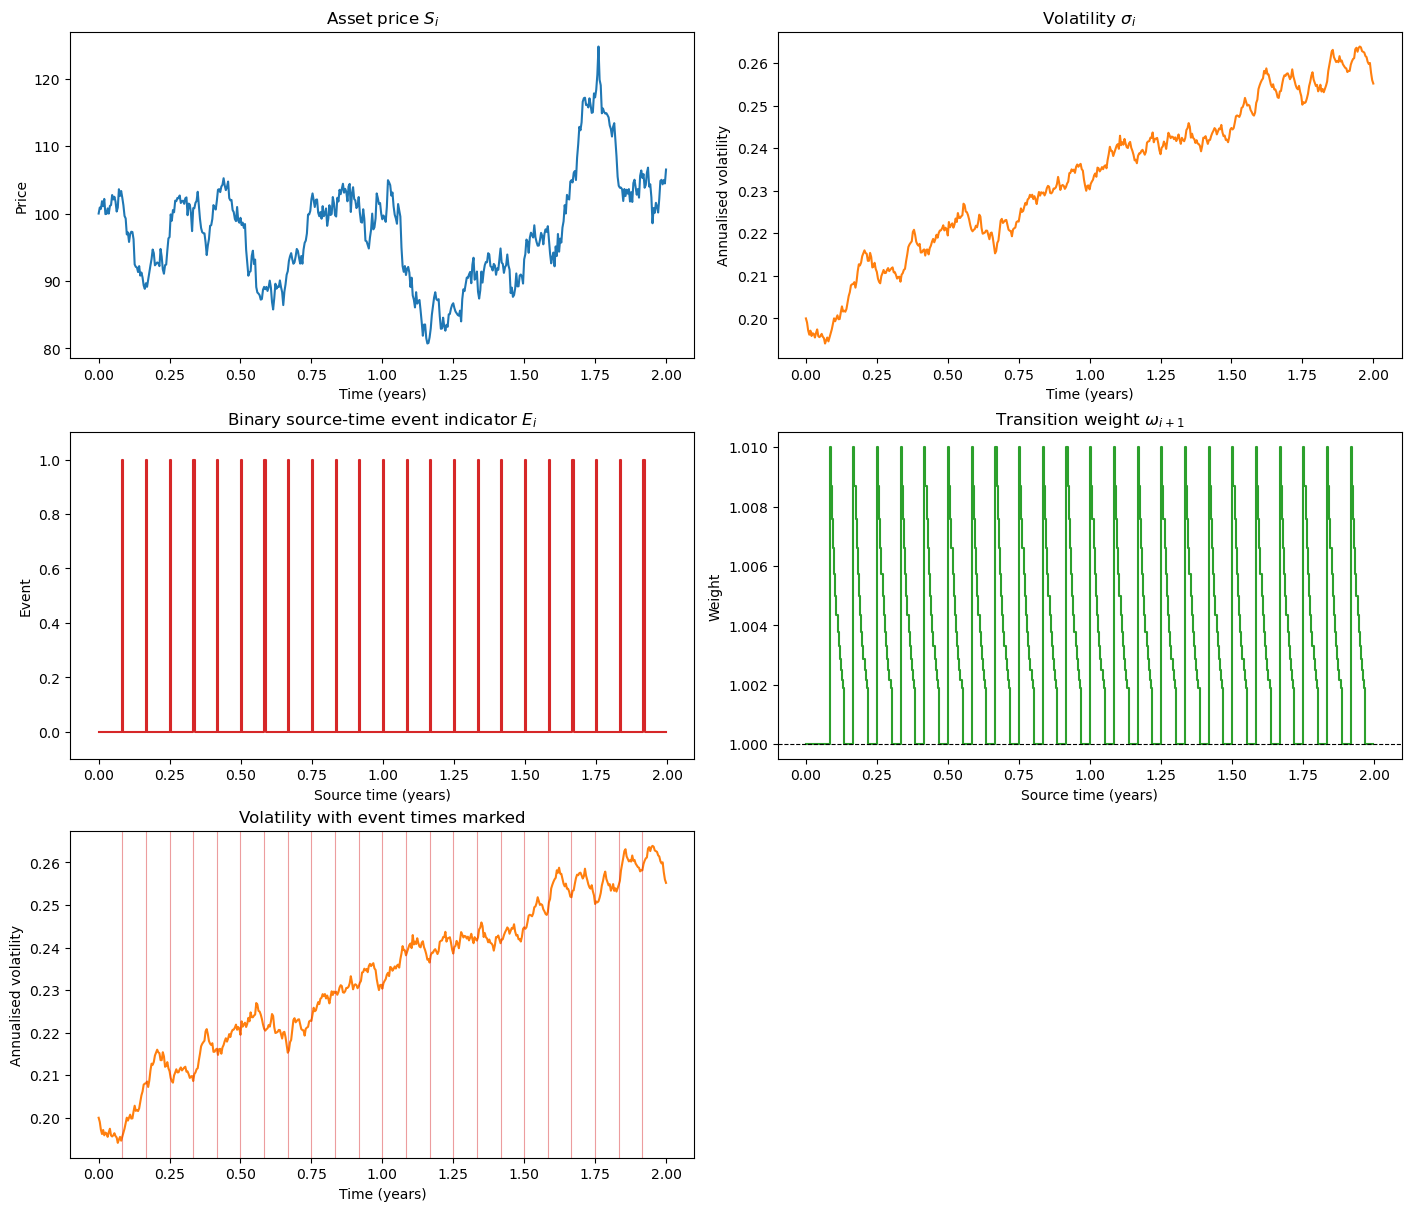

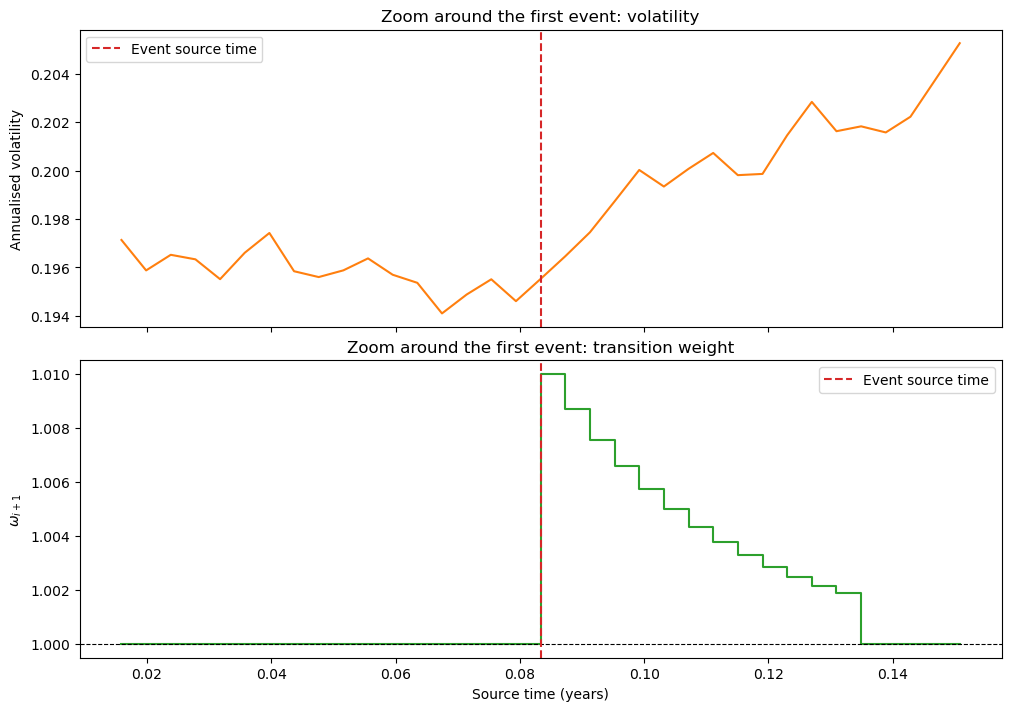

In [ ]:
states = reference_result['states']
transitions = reference_result['transitions']
first_event_time = event_times[0]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

axes[0].plot(states['t'], states['S'], color='tab:blue')
axes[0].set(title='Asset price $S_i$', xlabel='Time (years)', ylabel='Price')

axes[1].plot(states['t'], states['sigma'], color='tab:orange')
axes[1].set(title=r'Volatility $\sigma_i$', xlabel='Time (years)', ylabel='Annualised volatility')

axes[2].step(transitions['t'], transitions['event'], where='post', color='tab:red')
axes[2].set(title='Binary source-time event indicator $E_i$', xlabel='Source time (years)', ylabel='Event')
axes[2].set_ylim(-0.1, 1.1)

axes[3].step(transitions['t'], transitions['omega_next'], where='post', color='tab:green')
axes[3].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[3].set(title=r'Transition weight $\omega_{i+1}$', xlabel='Source time (years)', ylabel='Weight')

axes[4].plot(states['t'], states['sigma'], color='tab:orange')
for event_time in event_times:
    axes[4].axvline(event_time, color='tab:red', alpha=0.45, linewidth=0.8)
axes[4].set(title='Volatility with event times marked', xlabel='Time (years)', ylabel='Annualised volatility')

zoom_half_width = event_params['response_horizon'] + 5 / steps_per_year
zoom_states = states[states['t'].between(first_event_time - zoom_half_width, first_event_time + zoom_half_width)]
zoom_transitions = transitions[transitions['t'].between(first_event_time - zoom_half_width, first_event_time + zoom_half_width)]
axes[5].remove()

zoom_figure, (zoom_sigma_axis, zoom_weight_axis) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
zoom_sigma_axis.plot(zoom_states['t'], zoom_states['sigma'], color='tab:orange')
zoom_sigma_axis.axvline(first_event_time, color='tab:red', linestyle='--', label='Event source time')
zoom_sigma_axis.set(title='Zoom around the first event: volatility', ylabel='Annualised volatility')
zoom_sigma_axis.legend()

zoom_weight_axis.step(zoom_transitions['t'], zoom_transitions['omega_next'], where='post', color='tab:green')
zoom_weight_axis.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
zoom_weight_axis.axvline(first_event_time, color='tab:red', linestyle='--', label='Event source time')
zoom_weight_axis.set(title='Zoom around the first event: transition weight', xlabel='Source time (years)', ylabel='$\omega_{i+1}$')
zoom_weight_axis.legend()

plt.show()

## 10. Mechanical validation checks

These assertions check reproducibility, shock scaling reuse, source-time alignment, positivity, and the exact simulation identity. The event-free comparison holds the same standard-normal shocks fixed.

In [33]:
tolerance = reference_config['validation']['tolerance']
simulation_kwargs = {
    'time_grid': time_grid,
    'S0': reference_config['simulation']['S0'],
    'sigma0': reference_config['simulation']['sigma0'],
    'n': model_params['n'],
    'alpha_fn': alpha_fn,
    'nu_fn': nu_fn,
    'rho_fn': rho_fn,
    'event_weight_fn': event_weight_fn,
    'model_params': model_params,
    'event_times': event_times,
    'event_params': event_params,
}

# 1. Same seed reproduces both tables exactly.
repeat_result = simulate_event_volatility(**simulation_kwargs, seed=reference_config['simulation']['seed'])
pd.testing.assert_frame_equal(reference_result['states'], repeat_result['states'])
pd.testing.assert_frame_equal(reference_result['transitions'], repeat_result['transitions'])

# 2. A different seed changes the stochastic path.
different_seed_result = simulate_event_volatility(
    **simulation_kwargs, seed=reference_config['validation']['different_seed']
)
assert not np.allclose(reference_result['states']['S'], different_seed_result['states']['S'])

# 3 and 4. Fixed innovations isolate the event response.
fixed_innovations = generate_standard_normal_innovations(
    len(time_grid) - 1, reference_config['simulation']['seed']
)
reference_fixed = simulate_event_volatility(**simulation_kwargs, innovations=fixed_innovations)
no_event_params = dict(event_params)
no_event_params['amplitude'] = 0.0
no_event_result = simulate_event_volatility(
    **{**simulation_kwargs, 'event_params': no_event_params}, innovations=fixed_innovations
)
assert (no_event_result['transitions']['omega_next'] == 1.0).all()
before_first_event_states = reference_fixed['states']['t'] <= first_event_time + tolerance
np.testing.assert_allclose(
    reference_fixed['states'].loc[before_first_event_states, ['S', 'sigma', 'x']],
    no_event_result['states'].loc[before_first_event_states, ['S', 'sigma', 'x']],
    atol=tolerance,
    rtol=0.0,
)
before_first_event_transitions = reference_fixed['transitions']['t'] < first_event_time - tolerance
np.testing.assert_allclose(
    reference_fixed['transitions'].loc[before_first_event_transitions, ['F', 'x_next']],
    no_event_result['transitions'].loc[before_first_event_transitions, ['F', 'x_next']],
    atol=tolerance,
    rtol=0.0,
)
after_response_begins = reference_fixed['transitions']['t'] >= first_event_time - tolerance
assert np.any(
    np.abs(
        reference_fixed['transitions'].loc[after_response_begins, 'x_next'].to_numpy()
        - no_event_result['transitions'].loc[after_response_begins, 'x_next'].to_numpy()
    ) > tolerance
)

# 5. Exact simulated-weight recovery from stored F and x_next.
recovered_weight = (transitions['x_next'] / transitions['F']) ** (2 / model_params['n'])
max_weight_recovery_error = float(np.max(np.abs(recovered_weight - transitions['omega_next'])))
assert max_weight_recovery_error <= tolerance

# 6. An event at source time t_i changes that same transition's omega_next.
event_rows = transitions['event'].eq(1)
assert event_rows.any()
assert len(event_times) == int(transitions['event'].sum())
assert (transitions.loc[event_rows, 'omega_next'] > 1.0).all()
assert transitions.loc[transitions['t'] < first_event_time - tolerance, 'omega_next'].eq(1.0).all()

# 7. The recorded epsilon exactly reconstructs every price transition.
reconstructed_prices = (
    states['S'].iloc[:-1].to_numpy()
    * (1.0 + states['sigma'].iloc[:-1].to_numpy() * transitions['epsilon'].to_numpy())
)
np.testing.assert_allclose(reconstructed_prices, states['S'].iloc[1:].to_numpy(), atol=tolerance, rtol=0.0)

# 8. Positivity is preserved without clipping or numerical correction.
assert (states[['S', 'sigma', 'x']] > 0.0).all().all()
assert (transitions[['F', 'x_next', 'sigma_next', 'omega_next']] > 0.0).all().all()

# 9. Event weights are exactly one outside, and above one inside, response windows.
inside_response_window = response_window_mask(
    transitions['t'].to_numpy(), event_times, event_params['response_horizon']
)
assert (transitions.loc[~inside_response_window, 'omega_next'] == 1.0).all()
assert (transitions.loc[inside_response_window, 'omega_next'] > 1.0).all()

# 10. Short n=2 smoke test: same engine, variance-level theta, positive outputs.
n2_model_params = reference_config['validation']['n2_model']
n2_time_grid = np.arange(reference_config['validation']['n2_steps'] + 1, dtype=float) / steps_per_year
n2_event_times = periodic_event_times(n2_time_grid[0], n2_time_grid[-2], event_params)
n2_result = simulate_event_volatility(
    time_grid=n2_time_grid,
    S0=reference_config['simulation']['S0'],
    sigma0=reference_config['simulation']['sigma0'],
    n=n2_model_params['n'],
    alpha_fn=alpha_fn,
    nu_fn=nu_fn,
    rho_fn=rho_fn,
    event_weight_fn=event_weight_fn,
    model_params=n2_model_params,
    event_times=n2_event_times,
    event_params=event_params,
    seed=reference_config['validation']['n2_seed'],
)
assert set(n2_result) == {'states', 'transitions', 'diagnostics', 'config'}
assert (n2_result['states'][['S', 'sigma', 'x']] > 0.0).all().all()
assert (n2_result['transitions'][['F', 'x_next', 'sigma_next', 'omega_next']] > 0.0).all().all()

validation_summary = {
    'reproducibility_check': 'passed',
    'different_seed_check': 'passed',
    'no_event_check': 'passed',
    'event_free_path_comparison': 'passed',
    'exact_simulated_weight_recovery_check': 'passed',
    'event_alignment_check': 'passed',
    'event_schedule_transition_alignment_check': 'passed',
    'shared_shock_check': 'passed',
    'positivity_checks': 'passed',
    'reference_event_check': 'passed',
    'n2_smoke_test': 'passed',
    'max_abs_weight_recovery_error': max_weight_recovery_error,
}
for check, outcome in validation_summary.items():
    print(f'{check}: {outcome}')

reproducibility_check: passed
different_seed_check: passed
no_event_check: passed
event_free_path_comparison: passed
exact_simulated_weight_recovery_check: passed
event_alignment_check: passed
event_schedule_transition_alignment_check: passed
shared_shock_check: passed
positivity_checks: passed
reference_event_check: passed
n2_smoke_test: passed
max_abs_weight_recovery_error: 2.220446049250313e-16


## 11. Short findings and validation summary

The executed reference path is positive throughout without corrections. Its annualised volatility has minimum 0.194100, maximum 0.230954, and final value 0.221346. The periodic source-time events create visible one-sided increases in $\omega_{i+1}$, while the event-free comparison confirms no effect before the first response begins. This observed range does not show the previous runaway upward ratchet. All requested mechanical checks pass, including exact recovery of the simulated event weights and execution of the $n=2$ smoke test.

Implementation assumptions: event times are represented on the same annual-time scale as the supplied grid and are aligned to it in the reference case; externally supplied innovations are *standard-normal* shocks that the engine scales by $\sqrt{\Delta t_i}$; and the first $n=2$ test uses the same price equation but interprets `theta` as a variance level.